# EXPLORATORY DATA ANALYSIS(EDA)
* Exploratory Data Analysis (EDA) is the process of understanding, cleaning, and analyzing a dataset using statistical methods and visualizations before applying machine learning or advanced models.
EDA helps identify patterns, trends, relationships, missing values, and outliers in the data.

# ABOUT DATASET – Telco Customer Churn

* The Telco Customer Churn dataset contains customer-level information from a telecom company, used to analyze and predict customer churn behavior. The dataset includes details about customer demographics, services subscribed, contract information, billing, and payment methods.

* The main objective of this dataset is to understand why customers leave the service (churn) and to build a predictive model that can identify customers at high risk of churn

## IMPORT LIBRARIES
 * Imports required libraries for data manipulation, numerical operations, and visualization.Warnings are suppressed to keep the output clean and readable.

In [8]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## LOAD DATASET
* Loads the Telco Customer Churn dataset into a pandas DataFrame for analysis

In [9]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

## VIEW DATA

* Displays the first and last few records to understand the dataset structure and values.

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## DATASET SHAPE
* Returns the number of rows and columns present in the dataset

In [12]:
df.shape

(7043, 21)

## DATASET INFORMATION
* Provides information about data types, non-null values, and memory usage.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## COLUMN NAMES
* Displays all column names in the dataset.

In [14]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## FIX TOTALCHARGES DATA TYPE
* Converts TotalCharges column to numeric type.
Invalid values are converted to NaN for proper handling.

In [15]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


## CHECK MISSING VALUES
* Checks the number of missing values in each column.

In [16]:

df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

## HANDLE MISSING VALUES
* Removes rows containing missing values to maintain data quality.

In [17]:
df.dropna(inplace=True)

## DROP UNNECESSARY COLUMN
* Removes customerID column since it does not contribute to churn prediction.

In [18]:
#Drop unnecessary column
df.drop('customerID', axis=1, inplace=True)

## TARGET VARIABLE DISTRIBUTION
* Visualizes the distribution of churned vs non-churned customers.

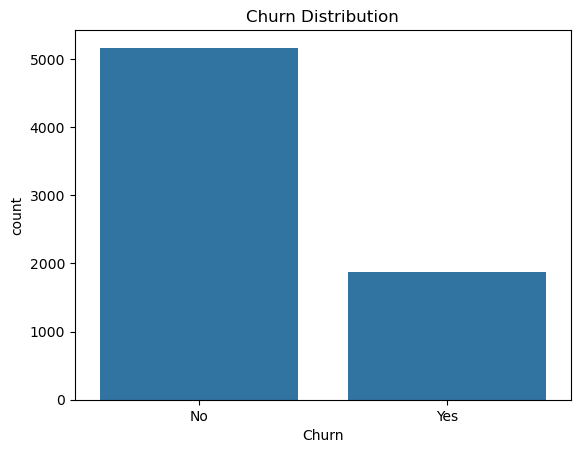

In [19]:

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## CHURN VS CONTRACT TYPE
* Shows churn behavior across different contract types.
Helps identify contracts with higher churn rates.

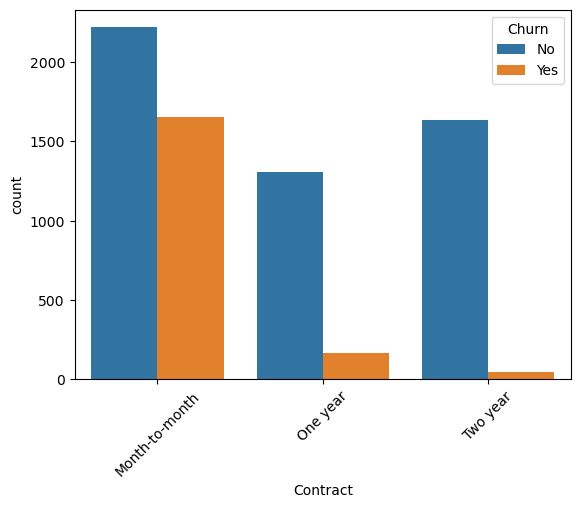

In [20]:

sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

## TENURE VS CHURN
* Compares customer tenure for churned and non-churned customers.

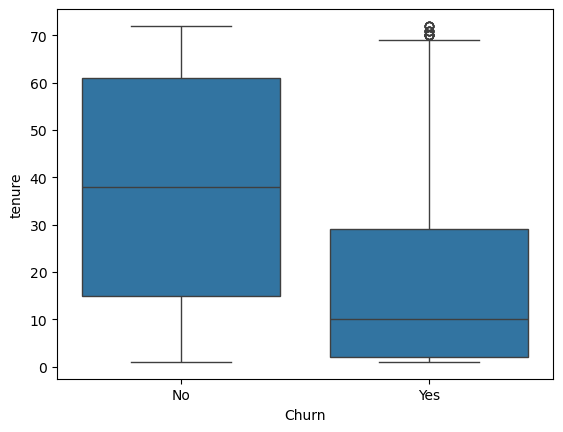

In [21]:

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

## MONTHLY CHARGES VS CHURN
* Analyzes how monthly charges impact customer churn.

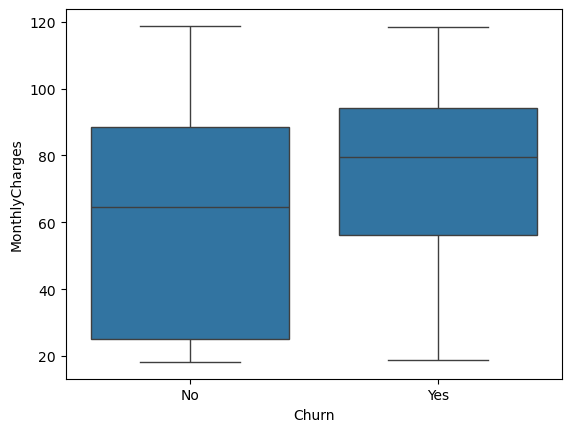

In [22]:

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

## KEY INSIGHTS
* Month-to-month customers churn more
* Low tenure customers have higher churn
* High monthly charges increase churn risk
* Summarizes important patterns observed from exploratory data analysis.

# DATA PREPROCESSING
## ENCODE CATEGORICAL VARIABLES
* Converts categorical features into numerical form using label encoding.

In [23]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


## FEATURE & TARGET SPLIT
* Separates input features and target variable for model training.

In [24]:

X = df.drop('Churn', axis=1)
y = df['Churn']

## TRAIN-TEST SPLIT
* Splits data into training and testing sets while maintaining churn distribution.

In [25]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## FEATURE SCALING
* Standardizes features to improve model performance and convergence.

In [26]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   

## MODEL BUILDING
* Builds and trains a Logistic Regression model for churn prediction.

In [27]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## MODEL EVALUATION
* Evaluates model performance using accuracy, confusion matrix, and classification metrics.

In [28]:

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7938877043354655
[[906 127]
 [163 211]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



## CONCLUSION

* This project successfully predicts customer churn using customer behavior and billing data. Logistic Regression achieved good accuracy and helped identify key churn drivers such as tenure, contract type, and monthly charges.